# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [ ]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [ ]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"


### Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [ ]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "dataset.csv")
file_name  = "dataset.csv"

---


# Test Environment


In [9]:
import pandas as pd

df = pd.read_csv("dataset.csv")

print(df.head())
print("Rows:", len(df), "Columns:", len(df.columns))

   Unnamed: 0 Manufacturer  Category     Screen  GPU  OS  CPU_core  \
0           0         Acer         4  IPS Panel    2   1         5   
1           1         Dell         3    Full HD    1   1         3   
2           2         Dell         3    Full HD    1   1         7   
3           3         Dell         4  IPS Panel    2   1         5   
4           4           HP         4    Full HD    2   1         7   

   Screen_Size_cm  CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_kg  Price  
0          35.560            1.6       8             256       1.60    978  
1          39.624            2.0       4             256       2.20    634  
2          39.624            2.7       8             256       2.20    946  
3          33.782            1.6       8             128       1.22   1244  
4          39.624            1.8       8             256       1.91    837  
Rows: 238 Columns: 13


In [10]:
missing_counts = df.isnull().sum()
cols_with_missing = missing_counts[missing_counts > 0].index.tolist()
print("Columns with missing values:", cols_with_missing)
print("Missing value counts per column:\n", missing_counts)

Columns with missing values: ['Screen_Size_cm', 'Weight_kg']
Missing value counts per column:
 Unnamed: 0        0
Manufacturer      0
Category          0
Screen            0
GPU               0
OS                0
CPU_core          0
Screen_Size_cm    4
CPU_frequency     0
RAM_GB            0
Storage_GB_SSD    0
Weight_kg         5
Price             0
dtype: int64


In [11]:
# Replace missing Screen_Size_cm with mode
df['Screen_Size_cm'] = df['Screen_Size_cm'].fillna(df['Screen_Size_cm'].mode().iloc[0])
# Replace missing Weight_kg with mean
df['Weight_kg'] = df['Weight_kg'].fillna(df['Weight_kg'].mean())


In [12]:
print(df[['Screen_Size_cm','Weight_kg']].head())
print("Missing after imputation:\n", df[['Screen_Size_cm','Weight_kg']].isnull().sum())

   Screen_Size_cm  Weight_kg
0          35.560       1.60
1          39.624       2.20
2          39.624       2.20
3          33.782       1.22
4          39.624       1.91
Missing after imputation:
 Screen_Size_cm    0
Weight_kg         0
dtype: int64


In [14]:
df['Screen_Size_cm'] = df['Screen_Size_cm'].astype(float)
df['Weight_kg'] = df['Weight_kg'].astype(float)


In [15]:
df['Screen_Size_inch'] = df['Screen_Size_cm'] / 2.54
df['Weight_pounds'] = df['Weight_kg'] * 2.20462262185
df = df.drop(columns=['Screen_Size_cm', 'Weight_kg'])

In [16]:
# Create indicator variables for Screen as df1
df1 = pd.get_dummies(df['Screen'], prefix='Screen')
# Append indicators to df
df = pd.concat([df, df1], axis=1)
# Drop the original Screen column
df = df.drop(columns=['Screen'])


In [18]:
# Example: rate provided numerically
usd_to_eur = 0.92
df['Price_EUR'] = (df['Price'] * usd_to_eur).astype(float)

# Optional: fetch rate from an API (no error handling shown)
# import requests
# usd_to_eur = float(requests.get("https://api.exchangerate-api.com/v4/latest/USD").json()["rates"]["EUR"])
# df['Price_EUR'] = (df['Price'] * usd_to_eur).astype(float)


In [19]:
print(df[['Price', 'Price_EUR']].head())

   Price  Price_EUR
0    978     899.76
1    634     583.28
2    946     870.32
3   1244    1144.48
4    837     770.04


In [20]:
import pandas as pd

# Sample DataFrame (usage example)
df = pd.DataFrame({
    'CPU_frequency': [2.4, 3.1, 1.8, None, 4.0],
    'Other': [10, 20, 30, 40, 50]
})

# Min-max normalization for CPU_frequency
min_val = df['CPU_frequency'].min()
max_val = df['CPU_frequency'].max()
df['CPU_frequency_norm'] = (df['CPU_frequency'] - min_val) / (max_val - min_val)

print(df)

   CPU_frequency  Other  CPU_frequency_norm
0            2.4     10            0.272727
1            3.1     20            0.590909
2            1.8     30            0.000000
3            NaN     40                 NaN
4            4.0     50            1.000000


In [1]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

In [5]:
import pandas as pd

df = pd.read_csv("dataset.csv", header=0)

description = df.describe(include='all')
print(description)

        Unnamed: 0 Manufacturer    Category   Screen         GPU          OS  \
count   238.000000          238  238.000000      238  238.000000  238.000000   
unique         NaN           11         NaN        2         NaN         NaN   
top            NaN         Dell         NaN  Full HD         NaN         NaN   
freq           NaN           71         NaN      161         NaN         NaN   
mean    118.500000          NaN    3.205882      NaN    2.151261    1.058824   
std      68.848868          NaN    0.776533      NaN    0.638282    0.235790   
min       0.000000          NaN    1.000000      NaN    1.000000    1.000000   
25%      59.250000          NaN    3.000000      NaN    2.000000    1.000000   
50%     118.500000          NaN    3.000000      NaN    2.000000    1.000000   
75%     177.750000          NaN    4.000000      NaN    3.000000    1.000000   
max     237.000000          NaN    5.000000      NaN    3.000000    2.000000   

          CPU_core  Screen_Size_cm  CPU

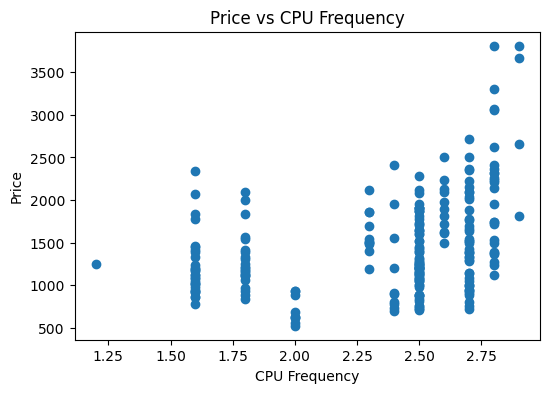

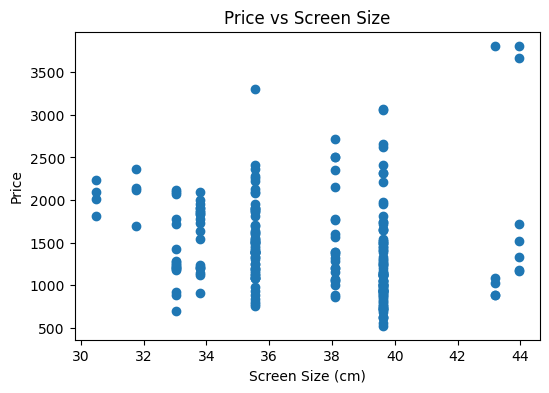

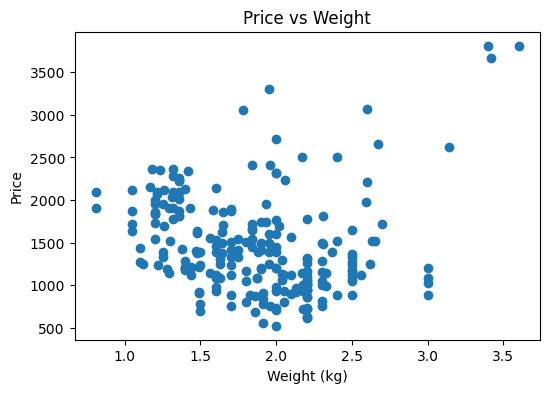

<Figure size 800x400 with 0 Axes>

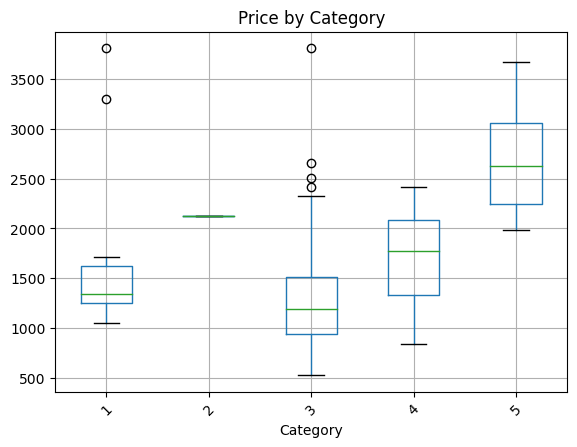

<Figure size 800x400 with 0 Axes>

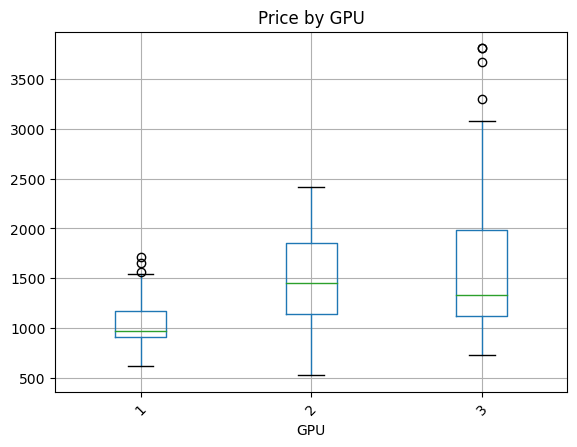

<Figure size 800x400 with 0 Axes>

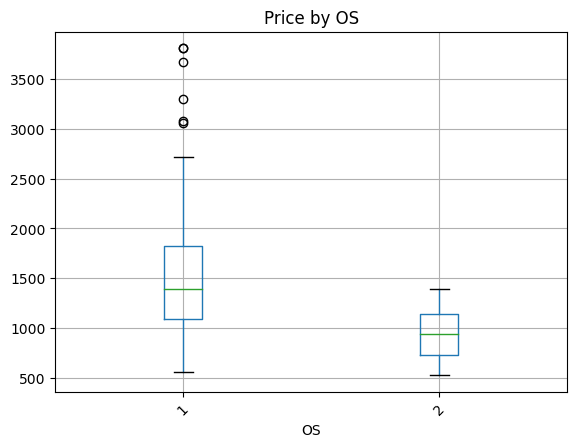

<Figure size 800x400 with 0 Axes>

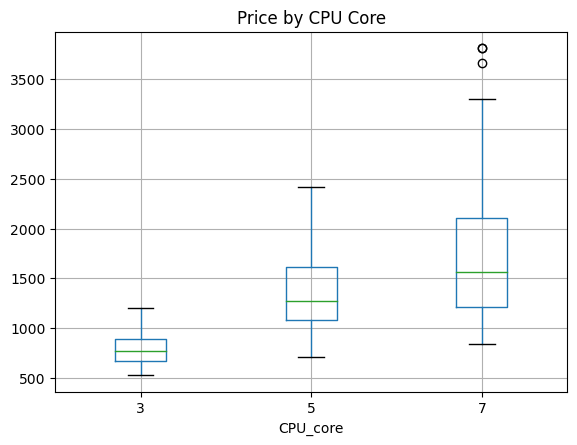

<Figure size 800x400 with 0 Axes>

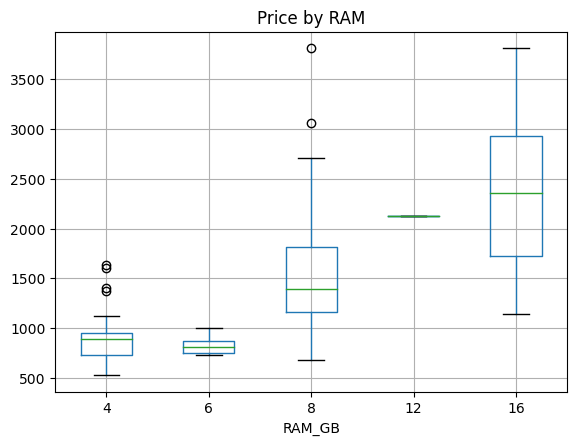

<Figure size 800x400 with 0 Axes>

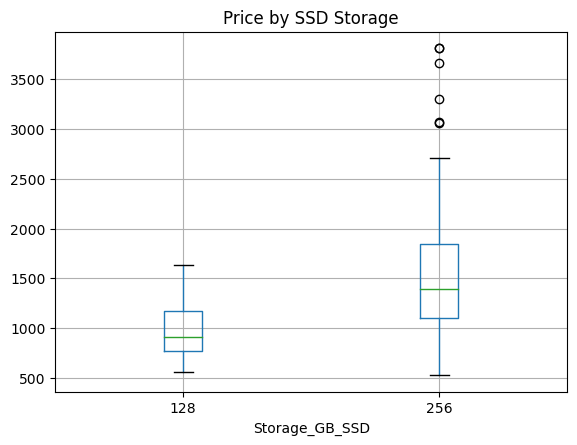

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('dataset.csv')

# Scatter plots
plt.figure(figsize=(6,4))
plt.scatter(df['CPU_frequency'], df['Price'])
plt.xlabel('CPU Frequency')
plt.ylabel('Price')
plt.title('Price vs CPU Frequency')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df['Screen_Size_cm'], df['Price'])
plt.xlabel('Screen Size (cm)')
plt.ylabel('Price')
plt.title('Price vs Screen Size')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df['Weight_kg'], df['Price'])
plt.xlabel('Weight (kg)')
plt.ylabel('Price')
plt.title('Price vs Weight')
plt.show()

# Boxplots
plt.figure(figsize=(8,4))
df.boxplot(column='Price', by='Category', rot=45)
plt.title('Price by Category')
plt.suptitle('')
plt.show()

plt.figure(figsize=(8,4))
df.boxplot(column='Price', by='GPU', rot=45)
plt.title('Price by GPU')
plt.suptitle('')
plt.show()

plt.figure(figsize=(8,4))
df.boxplot(column='Price', by='OS', rot=45)
plt.title('Price by OS')
plt.suptitle('')
plt.show()

plt.figure(figsize=(8,4))
df.boxplot(column='Price', by='CPU_core')
plt.title('Price by CPU Core')
plt.suptitle('')
plt.show()

plt.figure(figsize=(8,4))
df.boxplot(column='Price', by='RAM_GB')
plt.title('Price by RAM')
plt.suptitle('')
plt.show()

plt.figure(figsize=(8,4))
df.boxplot(column='Price', by='Storage_GB_SSD')
plt.title('Price by SSD Storage')
plt.suptitle('')
plt.show()

In [19]:
import pandas as pd
from scipy.stats import pearsonr

# Load local dataset
df = pd.read_csv('dataset.csv')

# Select numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Exclude Price column
features = [col for col in numeric_cols if col != 'Price']

# Calculate Pearson correlation
rows = []

for feat in features:
    x = df[feat]
    y = df['Price']
    
    valid = x.notna() & y.notna()
    
    r, p = pearsonr(x[valid], y[valid])
    
    rows.append({
        'Attribute': feat,
        'Pearson_r': r,
        'P_value': p
    })

# Create results dataframe
result_df = pd.DataFrame(rows)

# Display result
print(result_df)

        Attribute  Pearson_r       P_value
0      Unnamed: 0   0.321933  3.851058e-07
1        Category   0.286243  7.225696e-06
2             GPU   0.288298  6.166950e-06
3              OS  -0.221730  5.696643e-04
4        CPU_core   0.459398  7.912950e-14
5  Screen_Size_cm  -0.128233  5.009166e-02
6   CPU_frequency   0.366666  5.502463e-09
7          RAM_GB   0.549297  3.681561e-20
8  Storage_GB_SSD   0.243421  1.489892e-04
9       Weight_kg  -0.050707  4.410942e-01


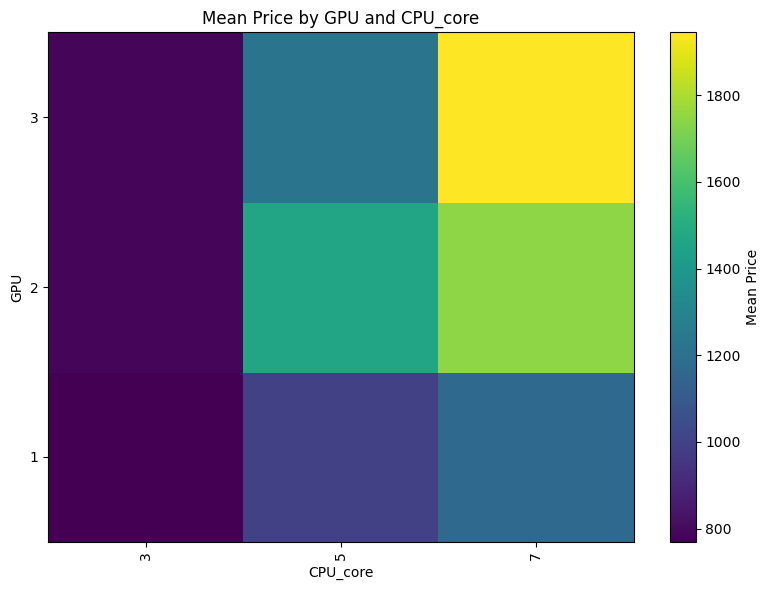

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pivot table: mean Price by GPU (rows) and CPU_core (columns)
pivot = df.pivot_table(index='GPU', columns='CPU_core', values='Price', aggfunc='mean')
pivot = pivot.fillna(0)

plt.figure(figsize=(8, 6))
plt.pcolor(pivot, cmap='viridis')
plt.colorbar(label='Mean Price')
plt.xlabel('CPU_core')
plt.ylabel('GPU')
plt.title('Mean Price by GPU and CPU_core')
plt.xticks(np.arange(0.5, len(pivot.columns), 1), pivot.columns, rotation=90)
plt.yticks(np.arange(0.5, len(pivot.index), 1), pivot.index)
plt.tight_layout()
plt.show()


In [1]:
import pandas as pd

# Read CSV file
df = pd.read_csv('dataset.csv', header=0)

# Display first 5 rows
print(df.head())

<ipython-input-1-88a73139633e>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


   Unnamed: 0 Manufacturer  Category     Screen  GPU  OS  CPU_core  \
0           0         Acer         4  IPS Panel    2   1         5   
1           1         Dell         3    Full HD    1   1         3   
2           2         Dell         3    Full HD    1   1         7   
3           3         Dell         4  IPS Panel    2   1         5   
4           4           HP         4    Full HD    2   1         7   

   Screen_Size_cm  CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_kg  Price  
0          35.560            1.6       8             256       1.60    978  
1          39.624            2.0       4             256       2.20    634  
2          39.624            2.7       8             256       2.20    946  
3          33.782            1.6       8             128       1.22   1244  
4          39.624            1.8       8             256       1.91    837  


In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('dataset.csv')

# Define source (X) and target (y)
X = df[['CPU_frequency']]
y = df['Price']

# Create and train model
lr = LinearRegression()
lr.fit(X, y)

# Predict values
y_pred = lr.predict(X)

# Calculate MSE and R²
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Display results
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 284583.4405868629
R² Score: 0.1344436321024326


In [5]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('dataset.csv')

# Source variable and target variable
X = df[['CPU_frequency']]
y = df['Price']

# Polynomial orders to test
orders = [2, 3, 5]

# Train and evaluate each model
for order in orders:
    poly = PolynomialFeatures(degree=order)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)

    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    print("Polynomial Order:", order)
    print("Mean Squared Error (MSE):", mse)
    print("R² Score:", r2)
    print("----------------------------")

Polynomial Order: 2
Mean Squared Error (MSE): 249022.66596751186
R² Score: 0.2426012074542374
----------------------------
Polynomial Order: 3
Mean Squared Error (MSE): 241024.86303848802
R² Score: 0.2669264079653101
----------------------------
Polynomial Order: 5
Mean Squared Error (MSE): 229137.29548055158
R² Score: 0.3030822706443398
----------------------------


In [4]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('dataset.csv')

# Source variable and target variable
X = df[['CPU_frequency']]
y = df['Price']

# Polynomial orders to test
orders = [2, 3, 5]

# Train and evaluate each model
for order in orders:
    poly = PolynomialFeatures(degree=order)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)

    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    print("Polynomial Order:", order)
    print("Mean Squared Error (MSE):", mse)
    print("R² Score:", r2)
    print("----------------------------")

Polynomial Order: 2
Mean Squared Error (MSE): 249022.66596751186
R² Score: 0.2426012074542374
----------------------------
Polynomial Order: 3
Mean Squared Error (MSE): 241024.86303848802
R² Score: 0.2669264079653101
----------------------------
Polynomial Order: 5
Mean Squared Error (MSE): 229137.29548055158
R² Score: 0.3030822706443398
----------------------------


In [6]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("dataset.csv")

# Select multiple source features and target
X = df[['CPU_frequency', 'CPU_core', 'RAM_GB', 'Storage_GB_SSD']]
y = df['Price']

# Create pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   # Fill missing values
    ('scaler', StandardScaler()),                  # Scale features
    ('poly', PolynomialFeatures(degree=2)),       # Polynomial feature generation
    ('model', LinearRegression())                 # Linear regression model
])

# Train the model
pipeline.fit(X, y)

# Make predictions
y_pred = pipeline.predict(X)

# Calculate metrics
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Display results
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 180793.74789915967
R² Score: 0.450118462804863


In [7]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("dataset.csv")

# Select features and target
X = df[['CPU_frequency', 'CPU_core', 'RAM_GB', 'Storage_GB_SSD']]
y = df['Price']

# Create pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   # Fill missing values
    ('scaler', StandardScaler()),                  # Scale data
    ('poly', PolynomialFeatures()),                # Polynomial features
    ('ridge', Ridge())                             # Ridge regression
])

# Define parameter grid for Grid Search
param_grid = {
    'poly__degree': [1, 2, 3],       # Polynomial degrees
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]   # Alpha values
}

# Perform Grid Search with Cross Validation
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,                     # 5-fold cross-validation
    scoring='r2'
)

# Train model
grid.fit(X, y)

# Best model
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X)

# Evaluate model
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

# Display results
print("Best Parameters:", grid.best_params_)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Best Parameters: {'poly__degree': 1, 'ridge__alpha': 1}
Mean Squared Error (MSE): 197431.55962687306
R² Score: 0.39951480203280354


In [3]:
import pandas as pd

# Read the CSV file
df = pd.read_csv("used_car_price_analysis.csv")

# Display first 5 rows
print(df.head())

     model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0   Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1    Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2    Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3   Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4   Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   

   price  
0  12000  
1  14000  
2  13000  
3  17500  
4  16500  


In [5]:
missing_columns = df.columns[df.isnull().any()]

print("Columns with missing values:")
print(missing_columns)

# 2. Replace missing values with mean of the column
for column in missing_columns:
    if df[column].dtype != 'object':   # Numeric columns only
        df[column] = df[column].fillna(df[column].mean())

# 3. Delete duplicate entries
df.drop_duplicates(inplace=True)

# Display first 5 rows after cleaning
print("\nUpdated DataFrame:")
print(df.head())

Columns with missing values:
Index([], dtype='object')

Updated DataFrame:
     model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0   Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1    Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2    Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3   Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4   Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   

   price  
0  12000  
1  14000  
2  13000  
3  17500  
4  16500  


In [8]:
numeric_df = df.select_dtypes(include=['number'])

# Find correlation of all attributes with 'price'
correlation = numeric_df.corr()['price']

# Remove price correlation with itself
correlation = correlation.drop('price')

# Get top 5 highly correlated attributes
top_5 = correlation.abs().sort_values(ascending=False).head(5)

# Print result
print("Top 5 attributes highly correlated with price:\n")
print(top_5)

Top 5 attributes highly correlated with price:

year          0.635715
mileage       0.530483
engineSize    0.411451
tax           0.405970
mpg           0.346263
Name: price, dtype: float64


In [11]:
attribute = 'fuelType'

# Count entries for each unique value
count_values = df[attribute].value_counts()

# Print the result
print(f"Count of entries for each unique value in '{attribute}':\n")
print(count_values)

Count of entries for each unique value in 'fuelType':

fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64


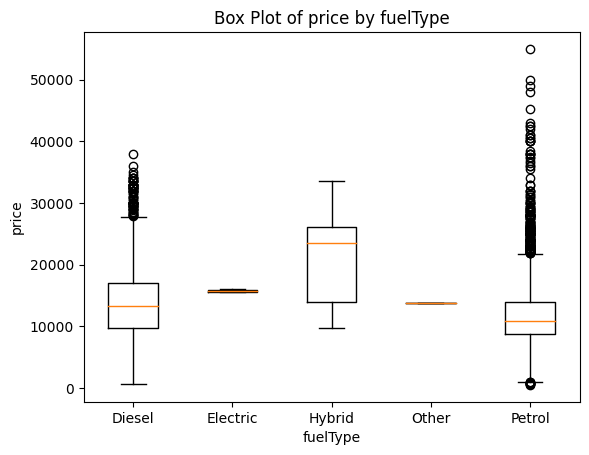

In [19]:
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("used_car_price_analysis.csv")

# Define attributes
source_attribute = 'fuelType'
target_attribute = 'price'

# Create boxplot data
groups = df.groupby(source_attribute)[target_attribute].apply(list)

# Plot boxplot
plt.boxplot(groups)
plt.xticks(range(1, len(groups.index) + 1), groups.index)

# Add labels and title
plt.xlabel(source_attribute)
plt.ylabel(target_attribute)
plt.title(f'Box Plot of {target_attribute} by {source_attribute}')

# Show plot
plt.show()

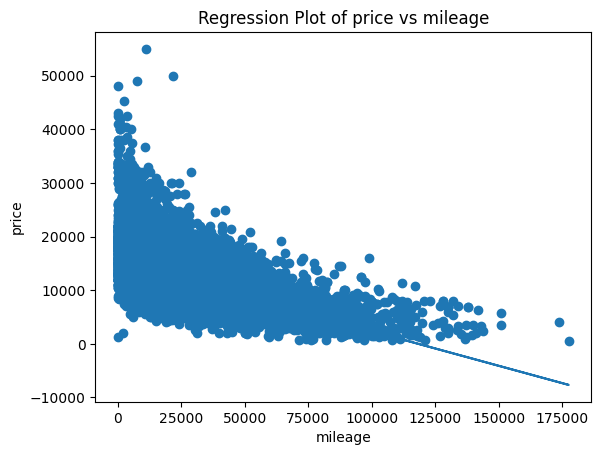

In [21]:
import numpy as np 
df = pd.read_csv("used_car_price_analysis.csv")

# Define source and target attributes
source_attribute = 'mileage'
target_attribute = 'price'

# Extract values
x = df[source_attribute]
y = df[target_attribute]

# Create scatter plot
plt.scatter(x, y)

# Create regression line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

# Add labels and title
plt.xlabel(source_attribute)
plt.ylabel(target_attribute)
plt.title(f'Regression Plot of {target_attribute} vs {source_attribute}')

# Show plot
plt.show()

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
df = pd.read_csv("used_car_price_analysis.csv")

# Define source and target variables
source_variable = 'mileage'
target_variable = 'price'

# Prepare data
X = df[[source_variable]]   # Independent variable
y = df[target_variable]     # Dependent variable

# Create and train model
model = LinearRegression()
model.fit(X, y)

# Predict values
y_pred = model.predict(X)

# Calculate R^2 score
r2 = r2_score(y, y_pred)

# Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred)

# Print results
print("R^2 Value:", r2)
print("Mean Squared Error (MSE):", mse)

R^2 Value: 0.28159910295661994
Mean Squared Error (MSE): 16148997.275487555


In [24]:
source_variables = ['mileage', 'engineSize', 'mpg', 'year']
target_variable = 'price'

# Prepare data
X = df[source_variables]   # Multiple independent variables
y = df[target_variable]    # Dependent variable

# Create and train Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Predict target values
y_pred = model.predict(X)

# Calculate R^2 score
r2 = r2_score(y, y_pred)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, y_pred)

# Print results
print("R^2 Value:", r2)
print("Mean Squared Error (MSE):", mse)

R^2 Value: 0.7266723604500769
Mean Squared Error (MSE): 6144156.173207869


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
source_attributes = ['mileage', 'engineSize', 'mpg', 'year']
target_variable = 'price'

# Prepare data
X = df[source_attributes]
y = df[target_variable]

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=2)),
    ('linear_regression', LinearRegression())
])

# Fit pipeline
pipeline.fit(X, y)

# Predict values
y_pred = pipeline.predict(X)

# Evaluate model
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

# Print results
print("R^2 Value:", r2)
print("Mean Squared Error (MSE):", mse)

R^2 Value: 0.7647894193406382
Mean Squared Error (MSE): 5287319.436635554


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
source_attributes = ['mileage', 'engineSize', 'mpg', 'year']
target_attribute = 'price'

# Prepare data
X = df[source_attributes]
y = df[target_attribute]

# 1. Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Create and fit Ridge Regression model
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)

# Predict on testing data
y_pred = ridge_model.predict(X_test)

# 3. Calculate MSE and R^2 values
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print("Mean Squared Error (MSE):", mse)
print("R^2 Value:", r2)

Mean Squared Error (MSE): 6151717.407298926
R^2 Value: 0.7255174361030912


In [34]:
# Define source attributes and target attribute
source_attributes = ['mileage', 'engineSize', 'mpg', 'year']
target_attribute = 'price'

# Prepare data
X = df[source_attributes]
y = df[target_attribute]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply polynomial features
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Scale the polynomial features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# Create and train Ridge Regression model
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_scaled, y_train)

# Predict values
y_pred = ridge_model.predict(X_test_scaled)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print("Mean Squared Error (MSE):", mse)
print("R^2 Value:", r2)

Mean Squared Error (MSE): 5791388.872326315
R^2 Value: 0.7415948814043254


In [36]:
from sklearn.model_selection import train_test_split, GridSearchCV
source_attributes = ['mileage', 'engineSize', 'mpg', 'year']
target_attribute = 'price'

# Prepare data
X = df[source_attributes]
y = df[target_attribute]

# 1. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Apply second degree polynomial transformation
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Scale the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# 3. Create Ridge Regression model
ridge = Ridge()

# Define parameter grid for alpha
parameters = {'alpha': [0.01, 0.1, 1, 10, 100]}

# Apply Grid Search with Cross Validation
ridge_cv = GridSearchCV(
    estimator=ridge,
    param_grid=parameters,
    cv=5
)

# Fit model
ridge_cv.fit(X_train_scaled, y_train)

# Best model
best_model = ridge_cv.best_estimator_

# Predict on test data
y_pred = best_model.predict(X_test_scaled)

# 4. Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print("Best Alpha Value:", ridge_cv.best_params_)
print("Mean Squared Error (MSE):", mse)
print("R^2 Value:", r2)

Best Alpha Value: {'alpha': 100}
Mean Squared Error (MSE): 5800719.881381466
R^2 Value: 0.7411785424993289


## Authors


[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
